In [19]:
from tigre.utilities.io import VarianDataLoader
from tigre.algorithms.single_pass_algorithms import FDK
from tigre.utilities.crop_CBCT import cropCBCT
import matplotlib.pyplot as plt
import pathlib
import numpy as np

In [20]:
mydir = "C:/CBCT_Scatter_Removal_Project/data/clinical/4100758/2021-07-06_101037/11528a87-b894-4239-846d-45d8fd1efeda/"

In [94]:
log_dir = pathlib.Path("C:/dev/scatter-unet/runs/20251212-202544")
keras_model = log_dir / "ckpt" / "model.keras"

In [ ]:
log_projs,geo,angles = VarianDataLoader(mydir,acdc=1,dps=1,fasks=1,keras_model=keras_model)

Loading Varian CBCT dataset: C:/CBCT_Scatter_Removal_Project/data/clinical/4100758/2021-07-06_101037/11528a87-b894-4239-846d-45d8fd1efeda/Acquisitions


100%|██████████| 900/900 [02:58<00:00,  5.05it/s]


Performing detector point scatter correction: 


10it [00:02,  3.91it/s]


Performing detector point scatter correction: 


...

887it [00:14, 60.52it/s]


Performing log normalization:


100%|██████████| 887/887 [00:14<00:00, 59.73it/s]


Performing ring artifact correction:


100%|██████████| 887/887 [01:11<00:00, 12.40it/s]


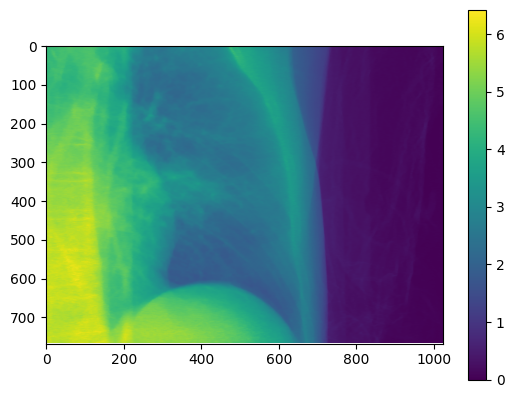

In [96]:
plt.imshow(log_projs[700])
plt.colorbar()
plt.show()

In [97]:
recon = FDK(log_projs,geo,angles)
rec = cropCBCT(recon)
rec[rec<0]=0

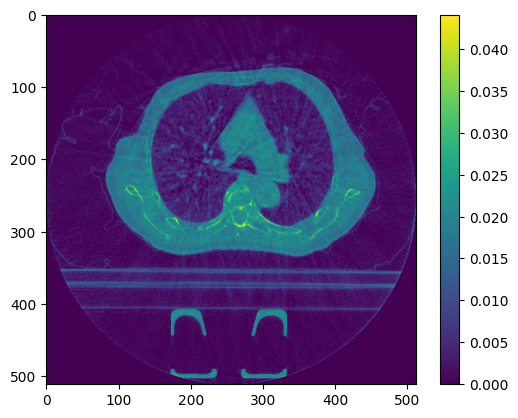

In [101]:
plt.imshow(rec[13].T)
plt.colorbar()

In [102]:
pt_num = 4100758
fname = str(log_dir).split('\\')[-1] + f"_pt{pt_num}_cnn_recon.npy"
np.save(log_dir / fname,rec)